# Deteccion de Caracteristicas

In [25]:
#Importar Librerias

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob

#Crear los detectores

akaze = cv2.AKAZE_create()
orb = cv2.ORB_create()

# Agregar las Imagenes

In [ ]:
notebook_dir = os.getcwd()
image_folder = os.path.join(notebook_dir)
image_files = glob.glob(os.path.join(image_folder, '*.jpg'))

if not image_files:
        print("No se encontraron imagenes.", image_folder)

# Detector Orb

In [20]:
def Orb_Detector():

    num_images = len(image_files)
    plt.figure(figsize=(5 * num_images, 5))

    for i, image in enumerate(image_files):
        img = cv2.imread(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kp_orb, des_orb = orb.detectAndCompute(img_gray, None)
        img_orb = cv2.drawKeypoints(img, kp_orb, None, color=(0,255,0), flags=0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
        plt.title(f"ORB detecto - {len(kp_orb)} puntos")
        plt.axis('off')
    plt.suptitle("Orb")
    plt.show()


# Detector Akaze

In [21]:
def Akaze_Detector():

    num_images = len(image_files)
    plt.figure(figsize=(5 * num_images, 5))

    for i, image in enumerate(image_files):
        img = cv2.imread(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kp_akaze, des_akaze = akaze.detectAndCompute(img_gray, None)
        img_akaze = cv2.drawKeypoints(img, kp_akaze, None, color=(0,255,0), flags=0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(img_akaze, cv2.COLOR_BGR2RGB))
        plt.title(f"Akaze detecto - {len(kp_akaze)} puntos")
        plt.axis('off')
    plt.suptitle("Akaze")
    plt.show()

# Ejecutamos los Detectores

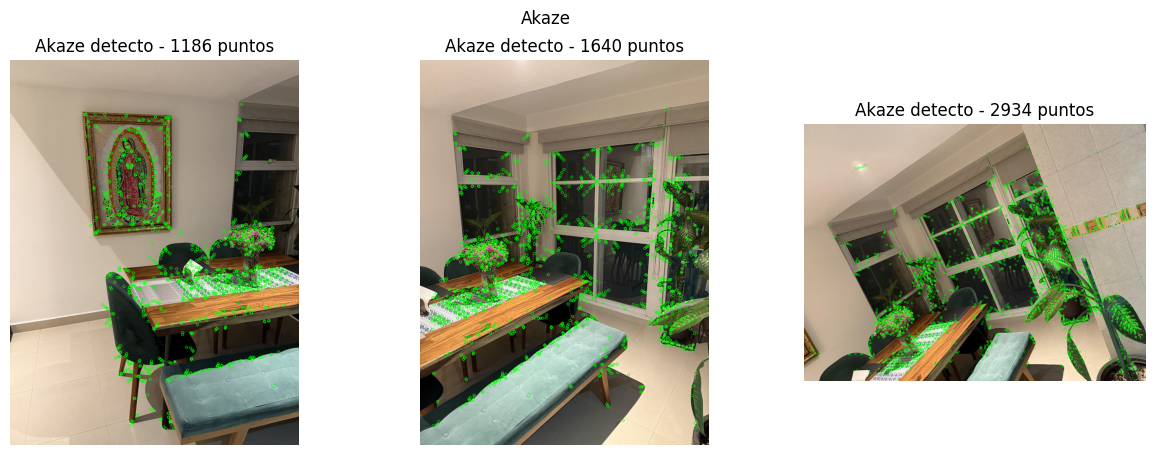

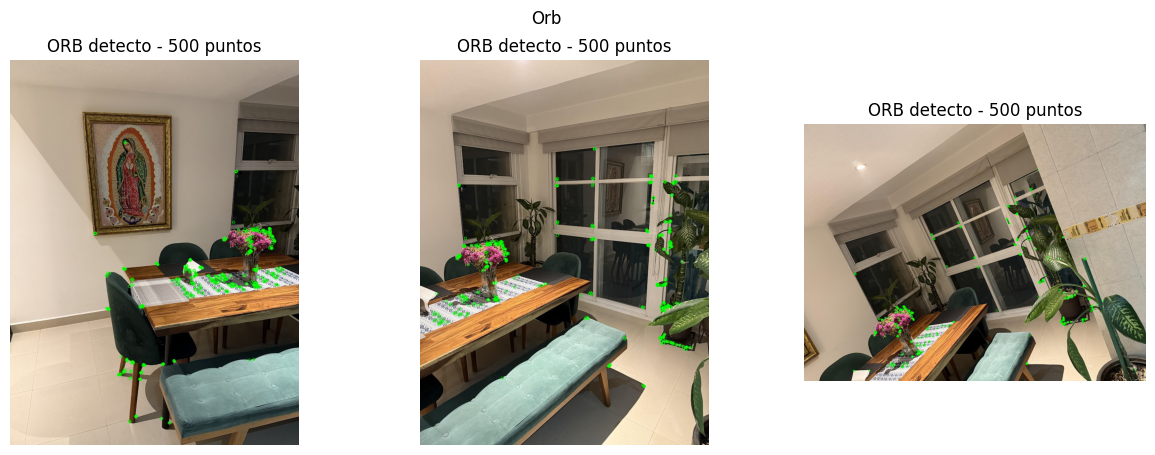

In [ ]:
# Llamamos los detectores
Akaze_Detector()
Orb_Detector()

# Emparejamiento

def Emparejamiento(img1, img2, detector, detector_txt):

    # Matcher
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print("No se detectaron suficientes características")
        return None, None, None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    # Lowe's Ratio Test
    good_matches = []
    for m_n in matches:
        if len(m_n) == 2:
            m, n = m_n
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)
    
    print(f"Características: {len(kp1)} en img1, {len(kp2)} en img2")
    print(f"Matches buenos: {len(good_matches)}")
    
    if len(good_matches) < 4:
        print("Insuficientes matches para homografía")
        return None, None, None
    
    # Extraer puntos
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    # RANSAC
    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
    inliers = mask.ravel().tolist()
    print(f"✓ Inliers (RANSAC): {sum(inliers)}/{len(inliers)}")
    
    # Visualizar matches
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, matchesMask=inliers, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return H, (pts1, pts2, inliers), img_matches

# Logica Emparejamiento

Características: 500 en img1, 500 en img2
Matches buenos: 78
✓ Inliers (RANSAC): 74/78
Características: 1186 en img1, 1640 en img2
Matches buenos: 286
✓ Inliers (RANSAC): 257/286
Características: 500 en img1, 500 en img2
Matches buenos: 33
✓ Inliers (RANSAC): 28/33
Características: 1186 en img1, 2934 en img2
Matches buenos: 108
✓ Inliers (RANSAC): 69/108


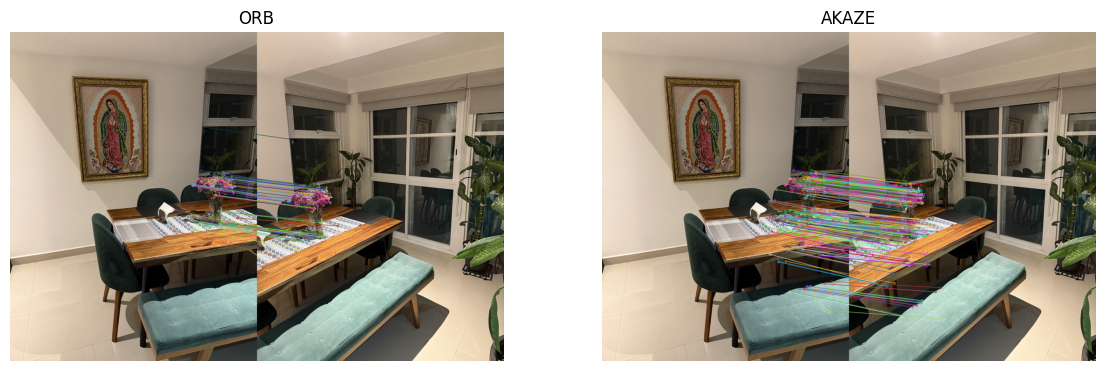

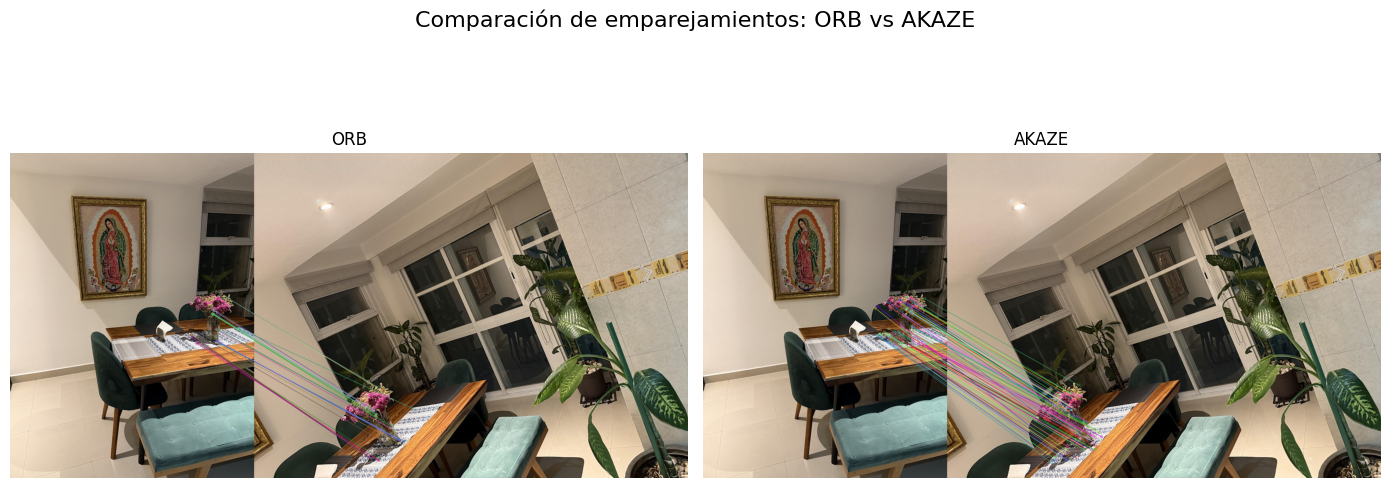

In [37]:
#Dibujamos los Matches

ref_img = cv2.imread(image_files[0])

for i, img in enumerate(image_files[1:], start=1):
    
    img = cv2.imread(img)

    # ORB
    H_orb, imageDataOrb, img_match_orb = Emparejamiento(ref_img, img, orb, "ORB")

    # AKAZE
    H_akaze, imageDataAkaze, img_match_akaze = Emparejamiento(ref_img, img, akaze, "AKAZE")

    plt.figure(figsize=(14, 6))

    if img_match_orb is not None:
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_match_orb, cv2.COLOR_BGR2RGB))
        plt.title(f"ORB")
        plt.axis('off')

    if img_match_akaze is not None:
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_match_akaze, cv2.COLOR_BGR2RGB))
        plt.title(f"AKAZE")
        plt.axis('off')
plt.suptitle("Comparación de emparejamientos: ORB vs AKAZE", fontsize=16)
plt.tight_layout()
plt.show()

# Combinar las tres imagenes

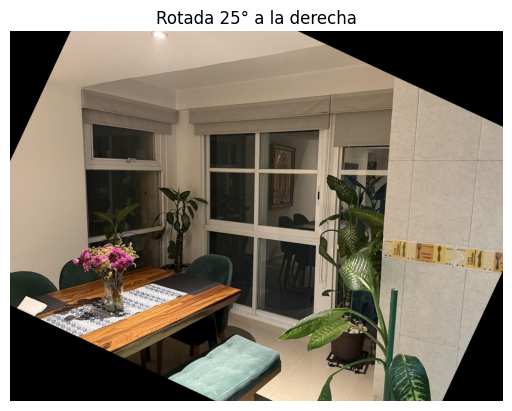

Características: 500 en img1, 500 en img2
Matches buenos: 78
✓ Inliers (RANSAC): 74/78


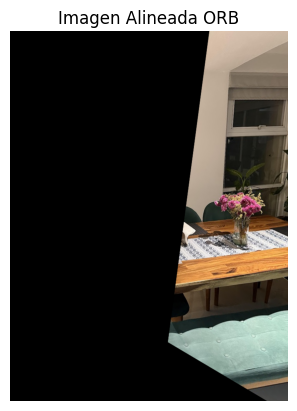

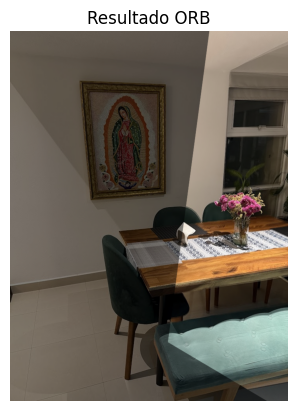

Características: 500 en img1, 500 en img2
Matches buenos: 59
✓ Inliers (RANSAC): 44/59


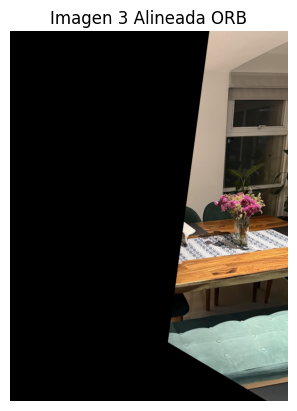

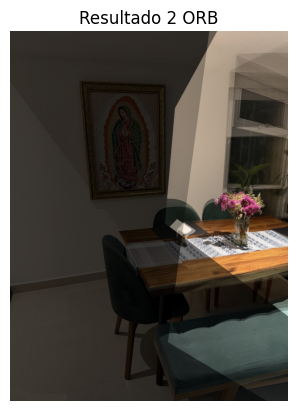

Características: 1186 en img1, 1640 en img2
Matches buenos: 286
✓ Inliers (RANSAC): 257/286


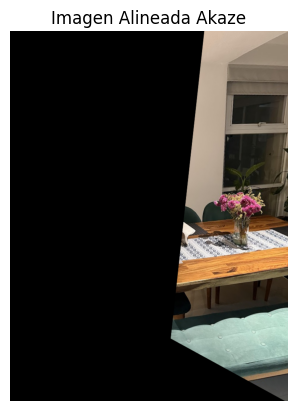

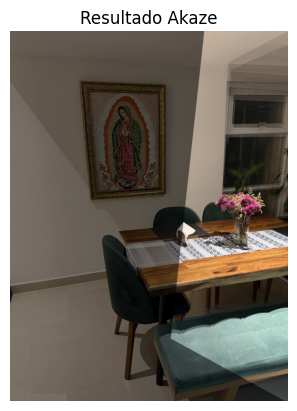

Características: 729 en img1, 2777 en img2
Matches buenos: 126
✓ Inliers (RANSAC): 97/126


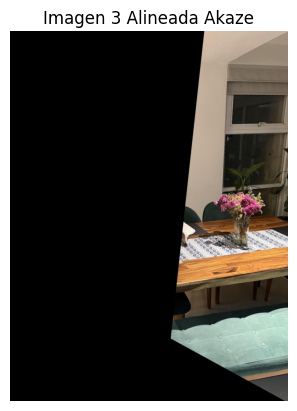

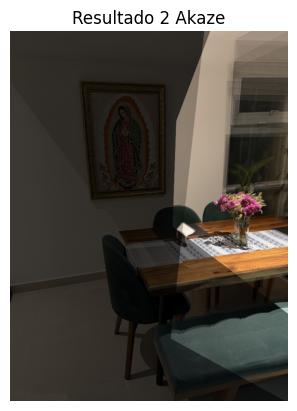

In [50]:
img1 = cv2.imread(image_files[0])
img2 = cv2.imread(image_files[1])
img3 = cv2.imread(image_files[2])

#Rotamos la Imagen 3

# Obtener dimensiones
(h, w) = img3.shape[:2]
center = (w // 2, h // 2)  # Centro de la imagen

# Matriz de rotación (ángulo negativo para rotar a la derecha)
angle = -25  # derecha -> negativo, izquierda -> positivo
scale = 1.0
M = cv2.getRotationMatrix2D(center, angle, scale)

# Aplicar rotación
img3 = cv2.warpAffine(img3, M, (w, h))

plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title(f"Rotada {abs(angle)}° a la derecha")
plt.axis('off')

plt.show()

# Orb

H1_orb, imageDataOrb, img_match_orb1 = Emparejamiento(img1, img2, orb, "ORB")

#Invertimos la Homografia
retval, H1_orb = cv2.invert(H1_orb)

h_f, w_f = img1.shape[:2]
img_lined = cv2.warpPerspective(img2, H1_orb, (w_f, h_f))
result = cv2.addWeighted(img1, 0.5, img_lined, 0.5, 0)

plt.imshow(cv2.cvtColor(img_lined, cv2.COLOR_BGR2RGB))
plt.title(f"Imagen Alineada ORB")
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado ORB")
plt.axis('off')
plt.show()

H2_orb, imageDataOrb2, img_match_orb2 = Emparejamiento(result, img3, orb, "ORB")

#Invertimos la Homografia
retval, H2_orb = cv2.invert(H2_orb)

h_f, w_f = result.shape[:2]
img2_lined = cv2.warpPerspective(img3, H2_orb, (w_f, h_f))
result = cv2.addWeighted(result, 0.5, img2_lined, 0.5, 0)

plt.imshow(cv2.cvtColor(img_lined, cv2.COLOR_BGR2RGB))
plt.title(f"Imagen 3 Alineada ORB")
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado 2 ORB")
plt.axis('off')
plt.show()

# AKAZE

H1_akaze, imageDataakaze1, img_match_akaze1 = Emparejamiento(img1, img2, akaze, "AKAZE")

#Invertimos la Homografia
retval, H1_akaze = cv2.invert(H1_akaze)

h_f, w_f = img1.shape[:2]
img_lined = cv2.warpPerspective(img2, H1_akaze, (w_f, h_f))
result = cv2.addWeighted(img1, 0.5, img_lined, 0.5, 0)

plt.imshow(cv2.cvtColor(img_lined, cv2.COLOR_BGR2RGB))
plt.title(f"Imagen Alineada Akaze")
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado Akaze")
plt.axis('off')
plt.show()

H2_akaze, imageDataAkaze2, img_match_akaze2 = Emparejamiento(result, img3, akaze, "AKAZE")

#Invertimos la Homografia
retval, H2_akaze = cv2.invert(H2_akaze)

h_f, w_f = result.shape[:2]
img2_lined = cv2.warpPerspective(img3, H2_akaze, (w_f, h_f))
result = cv2.addWeighted(result, 0.5, img2_lined, 0.5, 0)

plt.imshow(cv2.cvtColor(img_lined, cv2.COLOR_BGR2RGB))
plt.title(f"Imagen 3 Alineada Akaze")
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado 2 Akaze")
plt.axis('off')
plt.show()